Visualization routine for the 1D1D shock tube examples

In [121]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D

import numpy as np
import pandas as pd

from LoadTSV import *

In [122]:
# Matplotlib settings
WIDTH = 6.0 
HEIGHT = 2.5

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [123]:
# Solver and simulation parameters
M_vector = [4, 5]
closure_vec = ["Gram", "ExtGram", "Grad"] # Grad for M=5 (Kn=1.0 and -> infty) diverged -> negative density
Knudsen = [0.1, 1.0, 10.0]
source_vec = ["relaxation_source", "relaxation_source", "zero_source"]
T_end = 0.3
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# DVM
N = 1_000 
base_tree_level_DVM = 8
x_left_DVM = -5.0
x_right_DVM = 5.0
c_L = -6.0
c_R = 6.0

In [124]:
# Semi-analytical solution -> Collisionless
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

In [125]:
colors = ['blue', 'red', 'green', 'cyan', 'purple', 'black']
linestyles = ['--', '-', ':']

### Single Plots

In [126]:
# Plotting routine for density, velocity, and pressure profiles for different M, including DVM and semi-analytical solutions
def plotting(Moments, closure, Kn, source, figsize=(WIDTH, HEIGHT), show_legend=True):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    for i, M in enumerate(Moments):
        file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs.plot(x, rho, color=colors[i], ls=linestyles[0])
        twx.plot(x, v, color=colors[i], ls=linestyles[1])
        axs.plot(x, p, color=colors[i], ls=linestyles[2])
        axs.plot([], [], color=colors[i], ls='solid', label=f'$M={M}$')


        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/Shock/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.5))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.5))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')
    [axs.plot([], [], ls=linestyles[i], color='black', label=label_) for i, label_ in enumerate(['$\\rho$', '$v$', '$p$'])] 

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    if show_legend:
        axs.legend()
    fig.tight_layout()

    return fig, axs

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2541335372.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be 

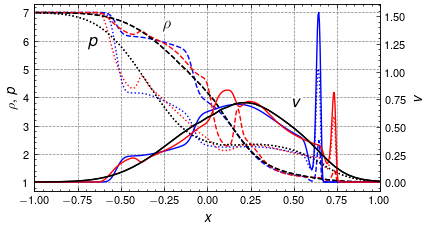

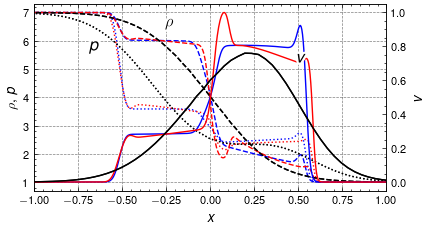

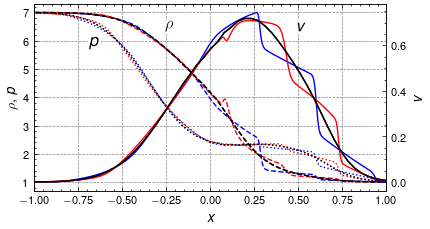

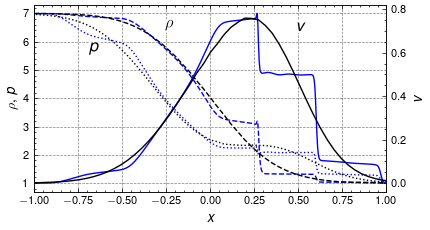

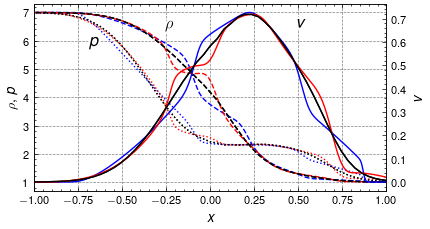

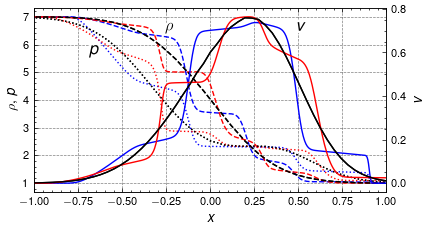

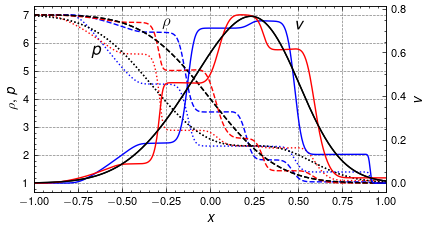

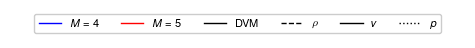

In [127]:
# Let's plot smth
Moments = [4, 5]
Knudsen_ = [0.1, 1.0]
for closure in ['Gram', 'Grad']:
    for Kn in Knudsen_:
        if closure == 'Grad' and Kn == 1.0:
            fig, axs = plotting([4], closure, Kn, 'relaxation_source', figsize=(.75*WIDTH, HEIGHT), show_legend=False)
            fig.show()
        else:
            fig, axs = plotting([4, 5], closure, Kn, 'relaxation_source', figsize=(.75*WIDTH, HEIGHT), show_legend=False)
            fig.show()
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_{closure}_Kn{Kn}.pdf')

Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]#!, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source'] #!'relaxation_source', 'zero_source']
closure = 'ExtGram'
for Kn, source in zip(Knudsen_, sources):
    fig, axs = plotting([4, 5], closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
    fig.show()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_{closure}_Kn{Kn}.pdf')
    else:
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_{closure}_zeroSource.pdf')

# Extract legend from one of the existing figures and save it as a separate PDF
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=6)
fig_leg.savefig('../out/Figures/ShockTube/legend_horizontal.pdf')

### ExtGram - Analysis

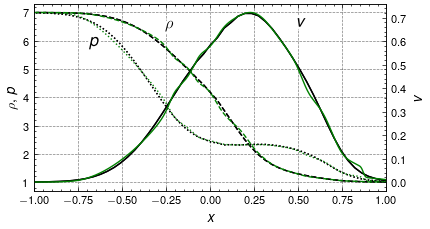

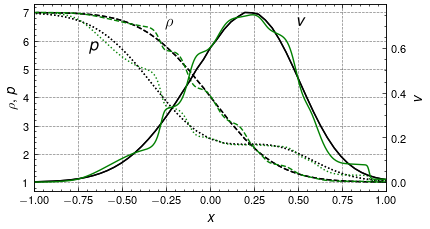

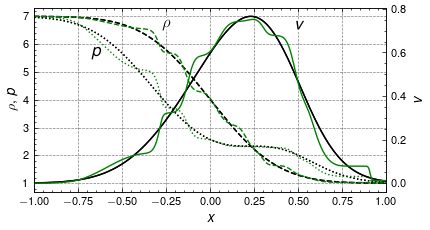

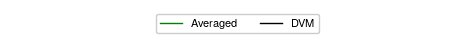

In [128]:
# Averaging M=4 and M=5 for ExtGram

Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
closure = 'ExtGram'
figsize = (.75*WIDTH, HEIGHT)

for Kn, source in zip(Knudsen_, sources):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    rho_vector, v_vector, p_vector = [], [], []
    for i, M in enumerate(Moments):
        file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2)
        theta = p / rho

        rho_vector.append(rho)
        v_vector.append(v)
        p_vector.append(p)

        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/Shock/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.5))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.5))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    rho_mean = np.mean(rho_vector, axis=0)
    v_mean = np.mean(v_vector, axis=0)
    p_mean = np.mean(p_vector, axis=0)
    axs.plot(x, rho_mean, color=colors[len(Moments)], ls=linestyles[0])
    twx.plot(x, v_mean, color=colors[len(Moments)], ls=linestyles[1])
    axs.plot(x, p_mean, color=colors[len(Moments)], ls=linestyles[2])

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[len(Moments)], ls='solid', label='Averaged')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    # axs.legend()
    fig.tight_layout()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_{closure}_Kn{Kn}_avg.pdf')
    else:
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_{closure}_zerosource_avg.pdf')

# To save JUST the legend as a separate file
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one of your existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=6)
fig_leg.savefig('../out/Figures/ShockTube/legend_horizontal_avg_method.pdf')

**Model Convergence**

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/1587777391.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/1587777391.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/1587777391.py:56: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/1587777391.py:57: UserWarning: linestyle is redundantly defined by the

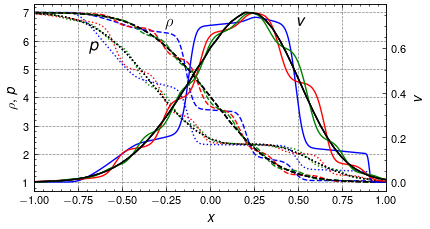

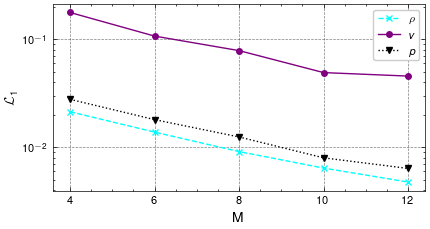

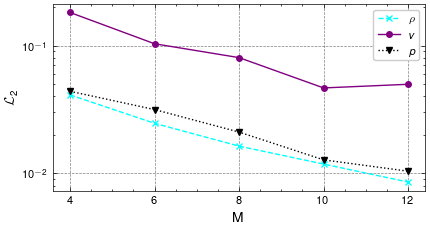

In [129]:
# Model Convergence

Moments = [4, 8, 12]
Moments_error = [4, 6, 8, 10, 12]
Kn = 1.0
source = 'relaxation_source'
closure = 'ExtGram'
fig, axs = plotting(Moments, closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
fig.show()
if source == 'relaxation_source':
    fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_8_12_{closure}_Kn{Kn}.pdf')
else:
    fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_8_12_{closure}_zeroSource.pdf')

# DVM
data_DVM = pd.read_csv(f'../out/Shock/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

x_DVM = data_DVM['x'].to_numpy()
rho_DVM = data_DVM['rho'].to_numpy()
v_DVM = data_DVM['v'].to_numpy()
p_DVM = data_DVM['p'].to_numpy()
theta_DVM = p_DVM / rho_DVM

rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

rho_vector, v_vector, p_vector = [], [], []
rho_L1, v_L1, p_L1 = [], [], []
rho_L2, v_L2, p_L2 = [], [], []

for i, M in enumerate(Moments_error):
    # Moments
    file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    rho_vector.append(rho)
    v = u[:, 1] / rho
    v_vector.append(v)
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    p_vector.append(p)
    theta = p / rho

    rho_L1.append(np.linalg.norm(rho_DVM_fct(x) - rho, 1) / np.linalg.norm(rho_DVM_fct(x), 1))
    rho_L2.append(np.linalg.norm(rho_DVM_fct(x) - rho, 2) / np.linalg.norm(rho_DVM_fct(x), 2))
    v_L1.append(np.linalg.norm(v_DVM_fct(x) - v, 1) / np.linalg.norm(v_DVM_fct(x), 1))
    v_L2.append(np.linalg.norm(v_DVM_fct(x) - v, 2) / np.linalg.norm(v_DVM_fct(x), 2))
    p_L1.append(np.linalg.norm(p_DVM_fct(x) - p, 1) / np.linalg.norm(p_DVM_fct(x), 1))
    p_L2.append(np.linalg.norm(p_DVM_fct(x) - p, 2) / np.linalg.norm(p_DVM_fct(x), 2))



fig_L1, axs_L1 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L1.semilogy(Moments_error, p_L1, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L1.legend()
axs_L1.set_xlabel('M')
axs_L1.set_ylabel('$\\mathcal{L}_1$')
axs_L1.set_xticks(Moments_error)

fig_L1.tight_layout()
fig_L1.savefig('../out/Figures/ShockTube/ShockTube_ShockTube_Even_L1.pdf')
fig_L1.show()



fig_L2, axs_L2 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L2.semilogy(Moments_error, v_L2, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L2.semilogy(Moments_error, p_L2, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L2.legend()
axs_L2.set_xlabel('M')
axs_L2.set_ylabel('$\\mathcal{L}_2$')
axs_L2.set_xticks(Moments_error)

fig_L2.tight_layout()
fig_L2.savefig('../out/Figures/ShockTube/ShockTube_ShockTube_Even_L2.pdf')
fig_L2.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3205302487.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3205302487.py:54: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3205302487.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3205302487.py:56: UserWarning: linestyle is redundantly defined by the

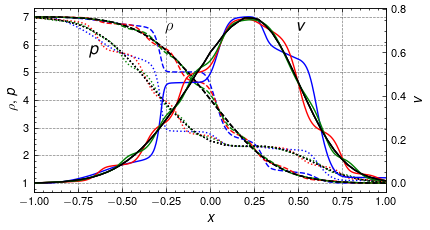

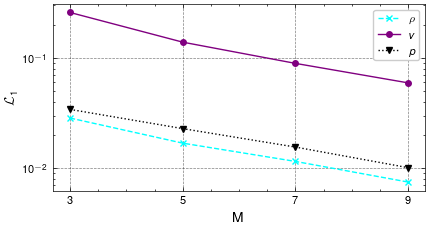

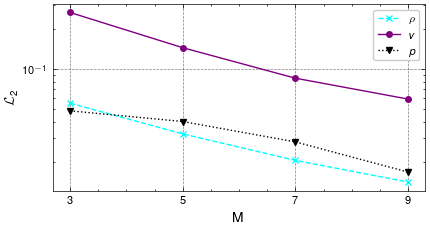

In [130]:
Moments = [5, 9, 13]
Moments_error = [3, 5, 7, 9]
fig, axs = plotting(Moments, closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
fig.show()
if source == 'relaxation_source':
    fig.savefig(f'../out/Figures/ShockTube/ShockTube_M5_9_13_{closure}_Kn{Kn}.pdf')
else:
    fig.savefig(f'../out/Figures/ShockTube/ShockTube_M5_9_13_{closure}_zeroSource.pdf')



# Model Convergence

# DVM
data_DVM = pd.read_csv(f'../out/Shock/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

x_DVM = data_DVM['x'].to_numpy()
rho_DVM = data_DVM['rho'].to_numpy()
v_DVM = data_DVM['v'].to_numpy()
p_DVM = data_DVM['p'].to_numpy()
theta_DVM = p_DVM / rho_DVM

rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

rho_vector, v_vector, p_vector = [], [], []
rho_L1, v_L1, p_L1 = [], [], []
rho_L2, v_L2, p_L2 = [], [], []

for i, M in enumerate(Moments_error):
    # Moments
    file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    rho_vector.append(rho)
    v = u[:, 1] / rho
    v_vector.append(v)
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    p_vector.append(p)
    theta = p / rho

    rho_L1.append(np.linalg.norm(rho_DVM_fct(x) - rho, 1) / np.linalg.norm(rho_DVM_fct(x), 1))
    rho_L2.append(np.linalg.norm(rho_DVM_fct(x) - rho, 2) / np.linalg.norm(rho_DVM_fct(x), 2))
    v_L1.append(np.linalg.norm(v_DVM_fct(x) - v, 1) / np.linalg.norm(v_DVM_fct(x), 1))
    v_L2.append(np.linalg.norm(v_DVM_fct(x) - v, 2) / np.linalg.norm(v_DVM_fct(x), 2))
    p_L1.append(np.linalg.norm(p_DVM_fct(x) - p, 1) / np.linalg.norm(p_DVM_fct(x), 1))
    p_L2.append(np.linalg.norm(p_DVM_fct(x) - p, 2) / np.linalg.norm(p_DVM_fct(x), 2))



fig_L1, axs_L1 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L1.semilogy(Moments_error, p_L1, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L1.legend()
axs_L1.set_xlabel('M')
axs_L1.set_ylabel('$\\mathcal{L}_1$')
axs_L1.set_xticks(Moments_error)

fig_L1.tight_layout()
fig_L1.savefig('../out/Figures/ShockTube/ShockTube_ShockTube_Odd_L1.pdf')
fig_L1.show()


fig_L2, axs_L2 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L2.semilogy(Moments_error, v_L2, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L2.semilogy(Moments_error, p_L2, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L2.legend()
axs_L2.set_xlabel('M')
axs_L2.set_ylabel('$\\mathcal{L}_2$')
axs_L2.set_xticks(Moments_error)

fig_L2.tight_layout()
fig_L2.savefig('../out/Figures/ShockTube/ShockTube_ShockTube_Odd_L2.pdf')
fig_L2.show()

<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2125293372.py:8: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='blue', label='$M\\in\{4,5\}$'),
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2125293372.py:9: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='red', label='$M\\in\{8,9\}$'),
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/2125293372.py:10: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='green', label='$M\\in\{12,13\}$'),


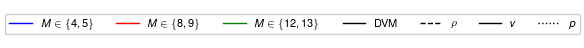

In [131]:
# And the legend

fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

custom_handles = [
    Line2D([0], [0], color='blue', label='$M\\in\{4,5\}$'),
    Line2D([0], [0], color='red', label='$M\\in\{8,9\}$'),
    Line2D([0], [0], color='green', label='$M\\in\{12,13\}$'),
    Line2D([0], [0], color='black', label='DVM'),
    Line2D([0], [0], color='black', linestyle='dashed', label='$\\rho$'),
    Line2D([0], [0], color='black', linestyle='solid', label='$v$'),
    Line2D([0], [0], color='black', linestyle='dotted', label='$p$'),
]

ax_leg.legend(handles=custom_handles, loc='center', ncol=7)
fig_leg.savefig('../out/Figures/ShockTube/legend_horizontal_model_convergence.pdf')

### Larger Shock ($\rho_L=30.0$)

In [132]:
def plotting_large_shock(Moments, closure, Kn, source, figsize=(WIDTH, HEIGHT), show_legend=True):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    for i, M in enumerate(Moments):
        file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs.plot(x, rho, color=colors[i], ls=linestyles[0])
        twx.plot(x, v, color=colors[i], ls=linestyles[1])
        axs.plot(x, p, color=colors[i], ls=linestyles[2])
        axs.plot([], [], color=colors[i], ls='solid', label=f'$M={M}$')


        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/Shock/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4*4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7*4, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.6))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4*4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7*4, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.6))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')
    [axs.plot([], [], ls=linestyles[i], color='black', label=label_) for i, label_ in enumerate(['$\\rho$', '$v$', '$p$'])] 

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    if show_legend:
        axs.legend()
    fig.tight_layout()

    return fig, axs

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3289742226.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_35547/3289742226.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


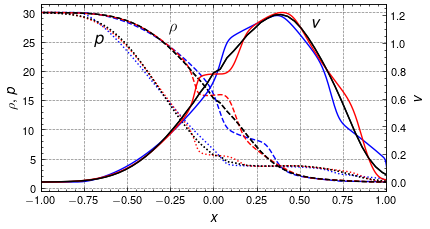

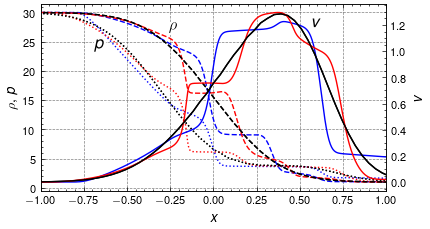

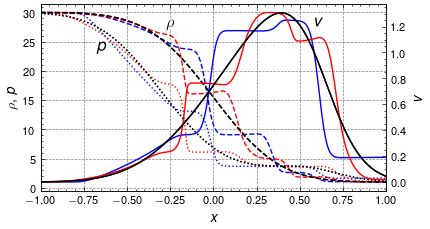

In [133]:
Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
closure = 'ExtGram'

rho_L = 30.0
maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

for Kn, source in zip(Knudsen_, sources):
    fig, axs = plotting_large_shock([4, 5], closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
    fig.show()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_rhoL{rho_L}_{closure}_Kn{Kn}.pdf')
    else:
        fig.savefig(f'../out/Figures/ShockTube/ShockTube_M4_5_rhoL{rho_L}_{closure}_zeroSource.pdf')

# Go Back to rho_L = 7.0 for next calculations
rho_L=7.0
maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T